In [ ]:
pip install yfinance pandas numpy matplotlib PyPortfolioOpt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 13.6 MB/s eta 0:00:00


In [ ]:
import yfinance as yf
import pandas as pd

# Select 50 stocks
tickers = [
    "AAPL","MSFT","NVDA","AMZN","GOOGL",
    "META","TSLA","JPM","V","MA",
    "UNH","HD","PG","XOM","LLY",
    "COST","ABBV","AVGO","KO","PEP",
    "MRK","BAC","ADBE","CRM","NFLX",
    "AMD","CSCO","WMT","MCD","INTC",
    "TMO","CVX","ORCL","QCOM","ABT",
    "LIN","NKE","IBM","AMGN","TXN",
    "UPS","CAT","RTX","SPGI","BLK",
    "GS","DE","PLD","LOW","NOW"
]

# Download daily adjusted prices
prices = yf.download(
    tickers,
    start="2020-01-01",
    end="2025-01-01",
    auto_adjust=True
)["Close"]

print(prices.head())
print(prices.shape)

[*********************100%***********************]  50 of 50 completed

Ticker           AAPL       ABBV        ABT        ADBE        AMD  \
Date                                                                 
2020-01-02  72.333870  68.210732  76.781097  334.429993  49.099998   
2020-01-03  71.630630  67.563293  75.845093  331.809998  48.599998   
2020-01-06  72.201416  68.096489  76.242455  333.709991  48.389999   
2020-01-07  71.861855  67.708015  75.818573  333.390015  48.250000   
2020-01-08  73.017853  68.187859  76.127647  337.869995  47.830002   

Ticker            AMGN       AMZN       AVGO        BAC         BLK  ...  \
Date                                                                 ...   
2020-01-02  196.748123  94.900497  27.633759  30.429457  435.306854  ...   
2020-01-03  195.412430  93.748497  26.930893  29.797640  430.679901  ...   
2020-01-06  196.911987  95.143997  26.890606  29.754959  431.047546  ...   
2020-01-07  195.060028  95.343002  26.798040  29.558577  433.801575  ...   
2020-01-08  195.207535  94.598503  26.463743  29.8574

In [3]:
import random

# Make results reproducible
random.seed(42)

portfolio_sizes = [5, 10, 20, 30, 50]

random_portfolios = {}

for size in portfolio_sizes:
    random_portfolios[size] = random.sample(tickers, size)

# Display selected stocks
for size, stocks in random_portfolios.items():
    print(f"\nPortfolio Size: {size}")
    print(stocks)


Portfolio Size: 5
['UPS', 'JPM', 'MSFT', 'PLD', 'AVGO']

Portfolio Size: 10
['COST', 'LLY', 'V', 'TSLA', 'SPGI', 'ABT', 'META', 'IBM', 'WMT', 'NVDA']

Portfolio Size: 20
['MSFT', 'META', 'XOM', 'LLY', 'ORCL', 'AMGN', 'NOW', 'LIN', 'PG', 'ABT', 'CSCO', 'DE', 'MCD', 'AVGO', 'AAPL', 'UNH', 'WMT', 'BAC', 'NKE', 'GOOGL']

Portfolio Size: 30
['XOM', 'LOW', 'BAC', 'TSLA', 'META', 'NFLX', 'DE', 'ADBE', 'RTX', 'AMGN', 'ABBV', 'NVDA', 'INTC', 'ABT', 'JPM', 'BLK', 'GS', 'KO', 'CRM', 'ORCL', 'SPGI', 'CAT', 'UPS', 'MSFT', 'PLD', 'LIN', 'MA', 'WMT', 'NKE', 'AMZN']

Portfolio Size: 50
['NFLX', 'AVGO', 'INTC', 'UPS', 'CRM', 'UNH', 'GS', 'ADBE', 'XOM', 'LOW', 'GOOGL', 'AMGN', 'BLK', 'ABT', 'COST', 'IBM', 'PLD', 'NOW', 'DE', 'QCOM', 'MRK', 'RTX', 'CVX', 'JPM', 'BAC', 'NKE', 'MSFT', 'CSCO', 'SPGI', 'ORCL', 'PG', 'V', 'NVDA', 'TSLA', 'TMO', 'AMZN', 'LIN', 'MCD', 'ABBV', 'CAT', 'PEP', 'WMT', 'TXN', 'AMD', 'HD', 'MA', 'KO', 'LLY', 'META', 'AAPL']


In [4]:
num_experiments = 100

portfolio_sets = {}

for size in portfolio_sizes:
    portfolio_sets[size] = []

    for _ in range(num_experiments):
        sample = random.sample(tickers, size)
        portfolio_sets[size].append(sample)

print(portfolio_sets[5][0])  # First 5-stock portfolio

['CRM', 'LLY', 'V', 'ORCL', 'CVX']


In [5]:
from pypfopt import EfficientFrontier
from pypfopt import expected_returns
from pypfopt import risk_models

# Example: first 5-stock portfolio
selected_stocks = portfolio_sets[5][0]

# Price data for these stocks
price_data = prices[selected_stocks]

# Calculate expected returns and covariance matrix
mu = expected_returns.mean_historical_return(price_data)
S = risk_models.sample_cov(price_data)

# Mean-Variance Optimization
ef = EfficientFrontier(mu, S)

# Maximize Sharpe Ratio
weights = ef.max_sharpe()

# Clean weights
cleaned_weights = ef.clean_weights()

print(cleaned_weights)

OrderedDict({'CRM': 0.0, 'LLY': 0.75, 'V': 0.0, 'ORCL': 0.25, 'CVX': 0.0})


In [6]:
optimized_weights = {}

for size in portfolio_sizes:

    optimized_weights[size] = []

    for portfolio in portfolio_sets[size]:

        data = prices[portfolio]

        mu = expected_returns.mean_historical_return(data)
        S = risk_models.sample_cov(data)

        ef = EfficientFrontier(mu, S)

        w = ef.max_sharpe()
        w = ef.clean_weights()

        optimized_weights[size].append(w)

print(optimized_weights[10][0])

OrderedDict({'AMD': 0.0, 'COST': 0.20536, 'MA': 0.0, 'CAT': 0.04879, 'BLK': 0.0, 'AAPL': 0.0, 'TSLA': 0.16123, 'WMT': 0.12014, 'LLY': 0.46448, 'HD': 0.0})


In [7]:
from pypfopt.discrete_allocation import DiscreteAllocation, get_latest_prices

# Investment budget
budget = 100000

# Latest stock prices
latest_prices = get_latest_prices(price_data)

# Greedy discrete allocation
da = DiscreteAllocation(
    cleaned_weights,
    latest_prices,
    total_portfolio_value=budget
)

allocation, leftover = da.greedy_portfolio()

print("Discrete Allocation:")
print(allocation)

print("Leftover Cash:", leftover)

Discrete Allocation:
{'LLY': 98, 'ORCL': 153}
Leftover Cash: 154.4407196044922


In [8]:
results = {}

budget = 100000

for size in portfolio_sizes:

    results[size] = []

    for i, portfolio in enumerate(portfolio_sets[size]):

        data = prices[portfolio]

        latest_prices = get_latest_prices(data)

        weights = optimized_weights[size][i]

        da = DiscreteAllocation(
            weights,
            latest_prices,
            total_portfolio_value=budget
        )

        allocation, leftover = da.greedy_portfolio()

        results[size].append({
            "allocation": allocation,
            "leftover_cash": leftover
        })

print(results[5][0])

{'allocation': {'LLY': 98, 'ORCL': 153}, 'leftover_cash': np.float64(154.4407196044922)}


In [10]:
import numpy as np

def calculate_tracking_error(weights, allocation, latest_prices):

    # Convert optimized weights to array
    target_weights = np.array(list(weights.values()))

    # Portfolio value after discrete allocation
    total_value = sum(
        allocation.get(stock, 0) * latest_prices[stock]
        for stock in weights.keys()
    )

    # Actual portfolio weights
    actual_weights = []

    for stock in weights.keys():
        value = allocation.get(stock, 0) * latest_prices[stock]
        actual_weights.append(value / total_value if total_value > 0 else 0)

    actual_weights = np.array(actual_weights)

    # Root Mean Squared Error
    te = np.sqrt(np.sum((target_weights - actual_weights) ** 2))

    return te

In [11]:
tracking_error = calculate_tracking_error(
    cleaned_weights,
    allocation,
    latest_prices
)

print("Tracking Error:", tracking_error)

Tracking Error: 0.3535533905932738


In [12]:
for size in portfolio_sizes:

    for i in range(len(results[size])):

        portfolio = portfolio_sets[size][i]
        data = prices[portfolio]

        latest_prices = get_latest_prices(data)

        weights = optimized_weights[size][i]

        allocation = results[size][i]["allocation"]

        te = calculate_tracking_error(
            weights,
            allocation,
            latest_prices
        )

        results[size][i]["tracking_error"] = te

In [13]:
print(results[5][0])

{'allocation': {'LLY': 98, 'ORCL': 153}, 'leftover_cash': np.float64(154.4407196044922), 'tracking_error': np.float64(0.0005986009985847815)}


In [14]:
import pandas as pd
import numpy as np

summary = []

for size in portfolio_sizes:

    te = [r["tracking_error"] for r in results[size]]
    cash = [r["leftover_cash"] for r in results[size]]

    summary.append({
        "Portfolio Size": size,
        "Mean Tracking Error": np.mean(te),
        "Std Tracking Error": np.std(te),
        "Mean Leftover Cash": np.mean(cash),
        "Std Leftover Cash": np.std(cash)
    })

summary_df = pd.DataFrame(summary)

print(summary_df)

   Portfolio Size  Mean Tracking Error  Std Tracking Error  \
0               5             0.001657        1.396284e-03   
1              10             0.002281        1.592056e-03   
2              20             0.002571        1.528220e-03   
3              30             0.003180        2.033530e-03   
4              50             0.002658        4.293222e-19   

   Mean Leftover Cash  Std Leftover Cash  
0          204.530509         180.101782  
1          178.353069         183.538895  
2          153.541234         180.104330  
3          150.781628         170.641038  
4           22.900360           0.000000  


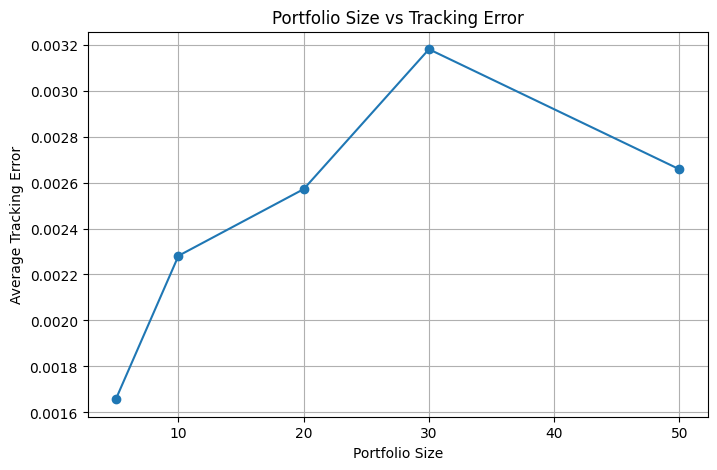

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    summary_df["Portfolio Size"],
    summary_df["Mean Tracking Error"],
    marker="o"
)

plt.xlabel("Portfolio Size")
plt.ylabel("Average Tracking Error")
plt.title("Portfolio Size vs Tracking Error")

plt.grid(True)

plt.show()

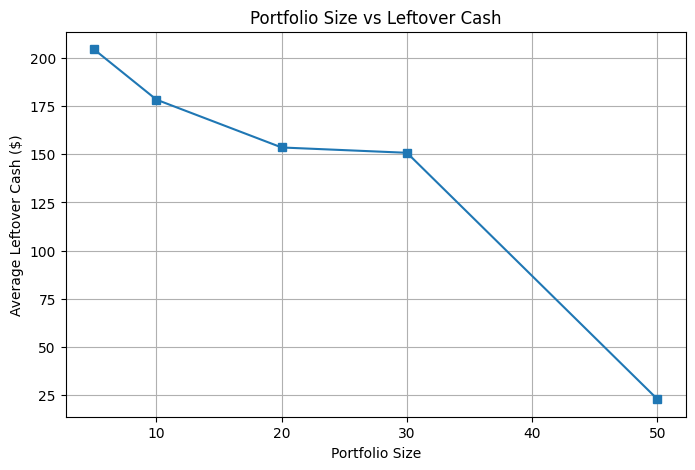

In [16]:
plt.figure(figsize=(8,5))

plt.plot(
    summary_df["Portfolio Size"],
    summary_df["Mean Leftover Cash"],
    marker="s"
)

plt.xlabel("Portfolio Size")
plt.ylabel("Average Leftover Cash ($)")
plt.title("Portfolio Size vs Leftover Cash")

plt.grid(True)

plt.show()

In [17]:

summary_df.to_csv(
    "portfolio_size_results.csv",
    index=False
)

print("Results saved successfully!")

Results saved successfully!
